**Iris Flower Classification**


Training a computer to recognize 3 types of iris flowers (Setosa, Versicolor, Virginica) just by looking at their measurements (sepal length, sepal width, petal length, petal width) .

**Step 1: Importing all the required libraries**

In [2]:
import pandas as pd #for file read and data manipulation
import numpy as np #for numerical calculation
import matplotlib.pyplot as plt #for visualization
import seaborn as sns #for advance visualization
from sklearn.model_selection import train_test_split #for spliting data into train and test sets
from sklearn.preprocessing import LabelEncoder #for converting the text into numbers
from sklearn.ensemble import RandomForestClassifier #our ML model
from sklearn.metrics import accuracy_score, classification_report #for checking our model's accuracy and result
import joblib #for saving and loading trained models

**Step 2: Loading the Dataset**

In [3]:
df = pd.read_csv('Iris.csv')

**Step 3: making a copy of dataset**

In [4]:
df_copy = df.copy()

**Step 4: Viewing first 5 rows**

In [5]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


**Step 5: Viewing last 5 rows**

In [6]:
df.tail()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica
149,150,5.9,3.0,5.1,1.8,Iris-virginica


**Step 6: Checking dataset shape**

In [7]:
df.shape

(150, 6)

**Step 7: Chceking Missing Vlaues**

In [8]:
df.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

we can see here that our dataset contains no missing values in each column

**Step 8: Counting Species**

In [11]:
df['Species'].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

it counts how many flowers belong to each species

and chcek if dataset is balanced or not

**Step 9: Dropping unnecessary column**

In [12]:
df_copy = df_copy.drop('Id',  axis = 1)

**Step 10: Statistical summary**

In [16]:
round(df.describe(), 2)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.00,150.00,150.00,150.00,150.00
mean,75.50,5.84,3.05,3.76,1.20
std,43.45,0.83,0.43,1.76,0.76
min,1.00,4.30,2.00,1.00,0.10
25%,38.25,5.10,2.80,1.60,0.30
50%,75.50,5.80,3.00,4.35,1.30
75%,112.75,6.40,3.30,5.10,1.80
max,150.00,7.90,4.40,6.90,2.50


by performing the above operations we can say that the give dataset is already clean

**Step 11: Data Visualisation**

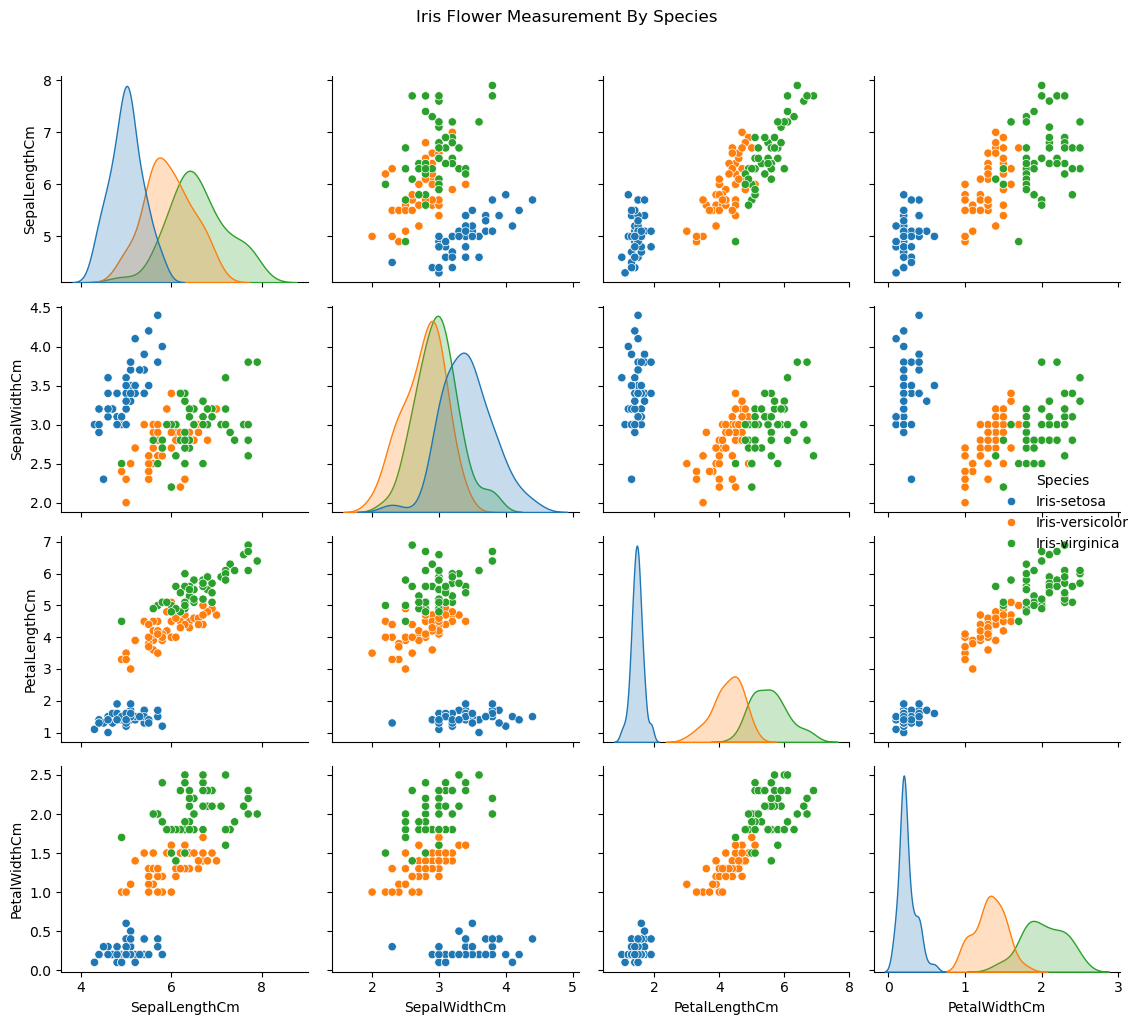

In [18]:
sns.pairplot(df_copy, hue = 'Species')
plt.suptitle('Iris Flower Measurement By Species', y = 1.02)
plt.tight_layout() #auto adjust spacing between graphs
plt.savefig('pairplot.png') #saves graph as image
plt.show()

I have used **PairPlot Matrix** for checking pair-wise relationship between all the numerical features at same time.

Here, it helps to visually see differences between flower species.

**Step 12: Selecting Input and Output Variables**

In [19]:
x = df_copy.drop(['Species'], axis = 1)

Stores the input features:

Inputs:
1. SepalLengthCm	
2. SepalWidthCm	
3. PetalLengthCm	
4. PetalWidthCm	

In [20]:
y = df_copy['Species']

Stores the Output feature

Output:
1. Species

**Step 13: Label Encoding**

As we know that ML models understands numbers only so we need to convert categorical data into numerical.

In [21]:
le = LabelEncoder()

In [22]:
y_encoded = le.fit_transform(y)

converts species into numbers by assigning numbers to each unique species in alphabetical order

eg:


Iris-setosa -> 0


Iris-versicolor -> 1


Iris-virginica -> 2

**Step 14: Splitting Dataset**

In [23]:
x_train, x_test, y_train, y_test = train_test_split(x, y_encoded, test_size = 0.2, random_state = 42)

training input and output data and 20% of data used for training to check model performance on unseen data.

I have also used random_state to keep splits same every time and makes the result reproducible.

In [33]:
print(f'Total Samples:    {len(df_copy)}')
print(f'Training Samples: {len(x_train)}')
print(f'Testing Samples:  {len(x_test)}')

Total Samples:    150
Training Samples: 120
Testing Samples:  30


**Step 15: Creating the Model**

In [24]:
model = RandomForestClassifier(n_estimators = 100, random_state = 42)

I have used RandomForestClassifier because it uses multiple decision trees and majority voting for making accurate predictions.

Here, n_estimators = 100 for creating 100 decision trees because more trees usually improve accuracy.

**Step 16: Training the model**

In [25]:
model.fit(x_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Trains the model using training data so that the model learns patterns from flower measurements

In [1]:
print('Model Training Completed')

Model Training Completed


**Step 17: Making Predictions [Testing the Model]**

In [27]:
y_predict = model.predict(x_test)

Predicts species for test data. This helps to evaluate model performance

**Step 18: Accuracy Score**

In [28]:
accuracy = accuracy_score(y_test, y_predict)

it compares the actual answers with the predicted answers to show how accurate the model is

**Step 19: Classification Report**

In [31]:
print(f'Model Accuracy: {accuracy * 100} %')
print()
print(classification_report(y_test, y_predict))

Model Accuracy: 100.0 %

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



classification_report prints the metrics like:


Precision - How many predicted values were correct


Recall - How many actual values were found correctly


F1-score - Balance of precision and recall


Support - Number of actual samples

classification_report() tells:

1. how accurate predictions are
2. which class is predicted well
3. where mistakes happen

**Step 20: Predicting New Flower**

In [43]:
new_flower = pd.DataFrame(
    [[5.1, 3.5, 1.4, 0.2]],
    columns = ['SepalLengthCm',
          'SepalWidthCm',
          'PetalLengthCm',
          'PetalWidthCm'])

creates the new flowder data

In [44]:
prediction = model.predict(new_flower)

In [49]:
predicted_species = le.inverse_transform(prediction) #to convert numbers back to species names.

print(f'Predicted Species: {predicted_species[0]}')

Predicted Species: Iris-setosa


**Step 21: saving the model**

In [50]:
joblib.dump((model, le), 'iris_model.pkl')

['iris_model.pkl']

saves:

1. trained model
2. label encoder

so we can reuse model later without training again